# Feature Engineering & AutoGluon - eksperymenty

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
)

from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt

## Wczytanie danych i baseline preprocessing

In [2]:
df = pd.read_csv("../data/01_raw/creditcard.csv")

X = df.drop(columns=["Class"])
y = df["Class"]

scaler = StandardScaler()
X[["Amount", "Time"]] = scaler.fit_transform(X[["Amount", "Time"]])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, fraudy: {y_train.sum()}")
print(f"Test:  {X_test.shape}, fraudy: {y_test.sum()}")

Train: (227845, 30), fraudy: 394
Test:  (56962, 30), fraudy: 98


In [3]:
baseline_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]
pr_auc_baseline = average_precision_score(y_test, y_proba_baseline)

print(f"Baseline PR-AUC: {pr_auc_baseline:.4f}")

Baseline PR-AUC: 0.7189


## Feature Engineering

In [4]:
# surowy Time przed skalowaniem do policzenia hour_of_day
time_raw_train = df.loc[X_train.index, "Time"]
time_raw_test = df.loc[X_test.index, "Time"]

amount_raw_train = df.loc[X_train.index, "Amount"]
amount_raw_test = df.loc[X_test.index, "Amount"]


def add_engineered_features(X, time_raw, amount_raw):
    X = X.copy()
    X["hour_of_day"] = (time_raw // 3600) % 24
    X["amount_log"] = np.log1p(amount_raw)
    for col in ["V17", "V14", "V12", "V10"]:
        X[f"amount_x_{col}"] = amount_raw * X[col]
    return X


X_train_fe = add_engineered_features(X_train, time_raw_train, amount_raw_train)
X_test_fe = add_engineered_features(X_test, time_raw_test, amount_raw_test)

X_train_fe.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,hour_of_day,amount_log,amount_x_V17,amount_x_V14,amount_x_V12,amount_x_V10
265518,1.413095,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,-0.388907,0.077641,-0.032248,-0.323963,20.0,2.118662,-5.604703,-0.487184,3.735231,-1.152189
180305,0.624644,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,-0.471198,0.002520,-0.069002,-0.341275,10.0,1.383791,-0.809819,2.155995,0.973424,0.851744
42664,-1.129186,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,0.913773,0.038049,0.185340,0.346835,11.0,5.171052,-126.880261,21.492854,318.710165,-351.874117
198723,0.796203,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.162068,0.018045,-0.063005,-0.328841,12.0,1.960095,0.443962,-1.191255,-4.406944,10.712338
82325,-0.746606,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.144622,-0.032580,-0.064194,-0.008994,16.0,4.467057,-34.399122,11.594154,-4.710385,-48.126027


In [5]:
model_fe = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_fe.fit(X_train_fe, y_train)

y_proba_fe = model_fe.predict_proba(X_test_fe)[:, 1]
pr_auc_fe = average_precision_score(y_test, y_proba_fe)
roc_auc_fe = roc_auc_score(y_test, y_proba_fe)

print(f"PR-AUC po FE: {pr_auc_fe:.4f}")
print(f"PR-AUC baseline: {pr_auc_baseline:.4f}")
print(f"Różnica: {pr_auc_fe - pr_auc_baseline:+.4f}")

PR-AUC po FE: 0.7370
PR-AUC baseline: 0.7189
Różnica: +0.0180


/home/xowski22/Desktop/credit_card_fraud_project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## AutoGluon

### Medium quality, 300s

In [6]:
train_data_ag = X_train_fe.copy()
train_data_ag["Class"] = y_train.values

train_data_ag.shape

(227845, 37)

In [8]:
predictor = TabularPredictor(
    label="Class",
    eval_metric="average_precision",
    path="../data/06_models/autogluon_medium",
).fit(train_data_ag, time_limit=600, presets="medium_quality")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2
CPU Count:          16
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.02 GB / 30.66 GB (32.7%)
Disk Space Avail:   221.33 GB / 912.79 GB (24.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/home/xowski22/Desktop/credit_card_fraud_project/data/06_models/autogluon_medium"
Train Data Rows:    227845
Train Data Columns: 36
Label Column:       Class
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_t

In [9]:
leaderboard = predictor.leaderboard(silent=True)
leaderboard[["model", "score_val", "fit_time"]]

,model,score_val,fit_time
0,WeightedEnsemble_L2,0.760989,11.130834
1,ExtraTreesGini,0.756289,8.083180
2,NeuralNetTorch,0.750699,65.670689
3,LightGBM,0.750402,0.806114
4,ExtraTreesEntr,0.750399,7.415896
5,RandomForestEntr,0.750399,49.537745
6,RandomForestGini,0.750399,87.390656
7,XGBoost,0.692995,0.844328
8,CatBoost,0.691886,1.197509
9,NeuralNetFastAI,0.691774,57.987100


In [10]:
y_proba_ag = predictor.predict_proba(X_test_fe)[1]
y_pred_ag = predictor.predict(X_test_fe)

pr_auc_ag = average_precision_score(y_test, y_proba_ag)
roc_auc_ag = roc_auc_score(y_test, y_proba_ag)

print(f"PR-AUC: {pr_auc_ag:.4f}")
print(f"ROC-AUC: {roc_auc_ag:.4f}")

PR-AUC: 0.8823
ROC-AUC: 0.9824


In [11]:
print(classification_report(y_test, y_pred_ag, target_names=["Normalna", "Fraud"]))

              precision    recall  f1-score   support

    Normalna       1.00      1.00      1.00     56864
       Fraud       0.96      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### Best Quality - 600s

In [12]:
predictor_best = TabularPredictor(
    label="Class",
    eval_metric="average_precision",
    path="../data/06_models/autogluon_best",
).fit(
    train_data_ag,
    time_limit=1200,
    presets="best_quality",
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2
CPU Count:          16
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.67 GB / 30.66 GB (34.8%)
Disk Space Avail:   221.21 GB / 912.79 GB (24.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify t

(_ray_fit pid=886297) [1000]	valid_set's binary_logloss: 0.00635074	valid_set's average_precision: 0.842651
(_ray_fit pid=886297) [2000]	valid_set's binary_logloss: 0.00648683	valid_set's average_precision: 0.847496


(_dystack pid=885168) 	0.7233	 = Validation score   (average_precision)
(_dystack pid=885168) 	27.68s	 = Training   runtime
(_dystack pid=885168) 	1.05s	 = Validation runtime
(_dystack pid=885168) Fitting model: LightGBM_BAG_L1 ... Training model for up to 160.01s of the 256.55s of remaining time.
(_dystack pid=885168) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=4.37%)
(_dystack pid=885168) 	0.7783	 = Validation score   (average_precision)
(_dystack pid=885168) 	8.69s	 = Training   runtime
(_dystack pid=885168) 	0.2s	 = Validation runtime
(_dystack pid=885168) Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 148.12s of the 244.66s of remaining time.
(_dystack pid=885168) 	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=16, gpus=0, mem=0.9/8.8 GB
(_dystack pid=885168) 	Warning: Reducing model 'n_estimators' from 300 -> 264 due to low time. Expected time usage reduced

In [13]:
leaderboard_best = predictor_best.leaderboard(silent=True)
leaderboard_best[["model", "score_val", "fit_time", "stack_level"]]

,model,score_val,fit_time,stack_level
0,WeightedEnsemble_L3,0.866808,637.002300,3
1,WeightedEnsemble_L2,0.865626,445.189533,2
2,CatBoost_BAG_L2,0.862793,576.374074,2
3,ExtraTreesGini_BAG_L2,0.859289,566.345163,2
4,RandomForestEntr_BAG_L2,0.858012,595.320661,2
5,CatBoost_BAG_L1,0.856509,47.355987,1
6,ExtraTreesEntr_BAG_L2,0.855799,565.736911,2
7,RandomForestEntr_BAG_L1,0.852785,51.996590,1
8,ExtraTreesGini_BAG_L1,0.851726,9.046701,1
9,ExtraTreesEntr_BAG_L1,0.849660,8.092793,1


In [14]:
y_proba_ag_best = predictor_best.predict_proba(X_test_fe)[1]
y_pred_ag_best = predictor_best.predict(X_test_fe)

pr_auc_ag_best = average_precision_score(y_test, y_proba_ag_best)
roc_auc_ag_best = roc_auc_score(y_test, y_proba_ag_best)

print(f"PR-AUC (best_quality):  {pr_auc_ag_best:.4f}")
print(f"ROC-AUC (best_quality): {roc_auc_ag_best:.4f}")

PR-AUC (best_quality):  0.8910
ROC-AUC (best_quality): 0.9801


## Podsumowanie

In [15]:
results = pd.DataFrame({
    "Model": [
        "Baseline (LogReg)",
        "LogReg + FE",
        "AutoGluon (medium_quality)",
        "AutoGluon (best_quality)",
    ],
    "PR-AUC": [pr_auc_baseline, pr_auc_fe, pr_auc_ag, pr_auc_ag_best],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_fe,
        roc_auc_ag,
        roc_auc_ag_best,
    ],
})

results.sort_values("PR-AUC", ascending=False)

,Model,PR-AUC,ROC-AUC
3,AutoGluon (best_quality),0.891037,0.980134
2,AutoGluon (medium_quality),0.882258,0.982424
1,LogReg + FE,0.736978,0.975232
0,Baseline (LogReg),0.718946,0.972167


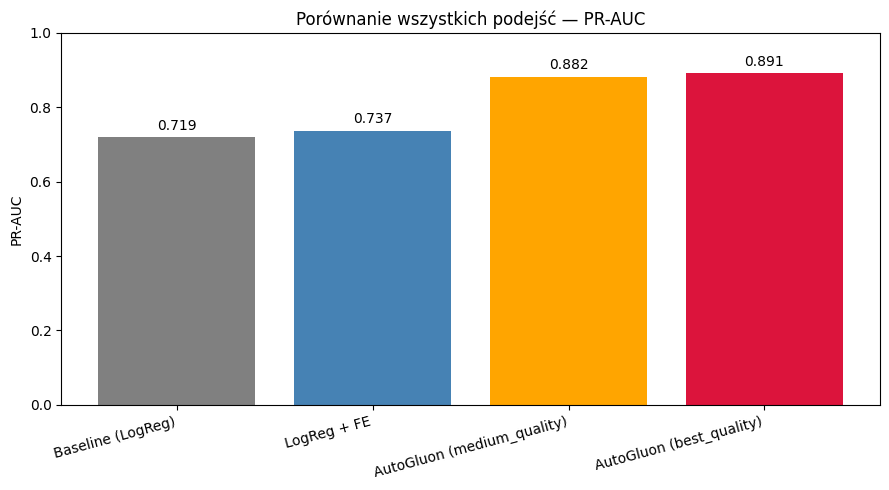

In [16]:
plt.figure(figsize=(9, 5))
colors = ["gray", "steelblue", "orange", "crimson"]
plt.bar(results["Model"], results["PR-AUC"], color=colors)
plt.ylabel("PR-AUC")
plt.title("Porównanie wszystkich podejść — PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(results["PR-AUC"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

In [17]:
import time

# pomiar throughput inferencji na tym samym X_test_fe dla obu modeli
start = time.time()
predictor.predict_proba(X_test_fe)
time_medium = time.time() - start

start = time.time()
predictor_best.predict_proba(X_test_fe)
time_best = time.time() - start

throughput_medium = len(X_test_fe) / time_medium
throughput_best = len(X_test_fe) / time_best

print(f"Medium quality: {time_medium:.2f}s, throughput: {throughput_medium:.0f} rows/s")
print(f"Best quality: {time_best:.2f}s, throughput: {throughput_best:.0f} rows/s")

Medium quality: 0.20s, throughput: 278360 rows/s
Best quality: 6.49s, throughput: 8772 rows/s


In [18]:
time_comparison = pd.DataFrame({
    "Model": ["AutoGluon (medium_quality)", "AutoGluon (best_quality)"],
    "Test PR-AUC": [pr_auc_ag, pr_auc_ag_best],
    "Inference throughput (rows/s)": [throughput_medium, throughput_best],
})

time_comparison

,Model,Test PR-AUC,Inference throughput (rows/s)
0,AutoGluon (medium_quality),0.882258,278359.807536
1,AutoGluon (best_quality),0.891037,8771.804113


## Selekcja cech

In [19]:
test_data_ag = X_test_fe.copy()
test_data_ag["Class"] = y_test.values

importance = predictor.feature_importance(test_data_ag)
importance.sort_values("importance", ascending=False)

Computing feature importance via permutation shuffling for 36 features using 5000 rows with 5 shuffle sets...
	12.6s	= Expected runtime (2.52s per shuffle set)
	3.24s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
V14,0.041391,0.059010,0.095929,5,0.162892,-0.080111
V12,0.017104,0.010618,0.011360,5,0.038968,-0.004759
V10,0.014277,0.024753,0.133336,5,0.065243,-0.036690
V4,0.008573,0.012231,0.096042,5,0.033757,-0.016610
V16,0.008336,0.008039,0.040631,5,0.024889,-0.008217
amount_x_V12,0.007916,0.008418,0.051677,5,0.025250,-0.009418
V7,0.006459,0.007952,0.071736,5,0.022832,-0.009913
Time,0.005176,0.009171,0.137757,5,0.024060,-0.013708
V20,0.004823,0.003427,0.017311,5,0.011879,-0.002234
Amount,0.004746,0.003616,0.021306,5,0.012193,-0.002700


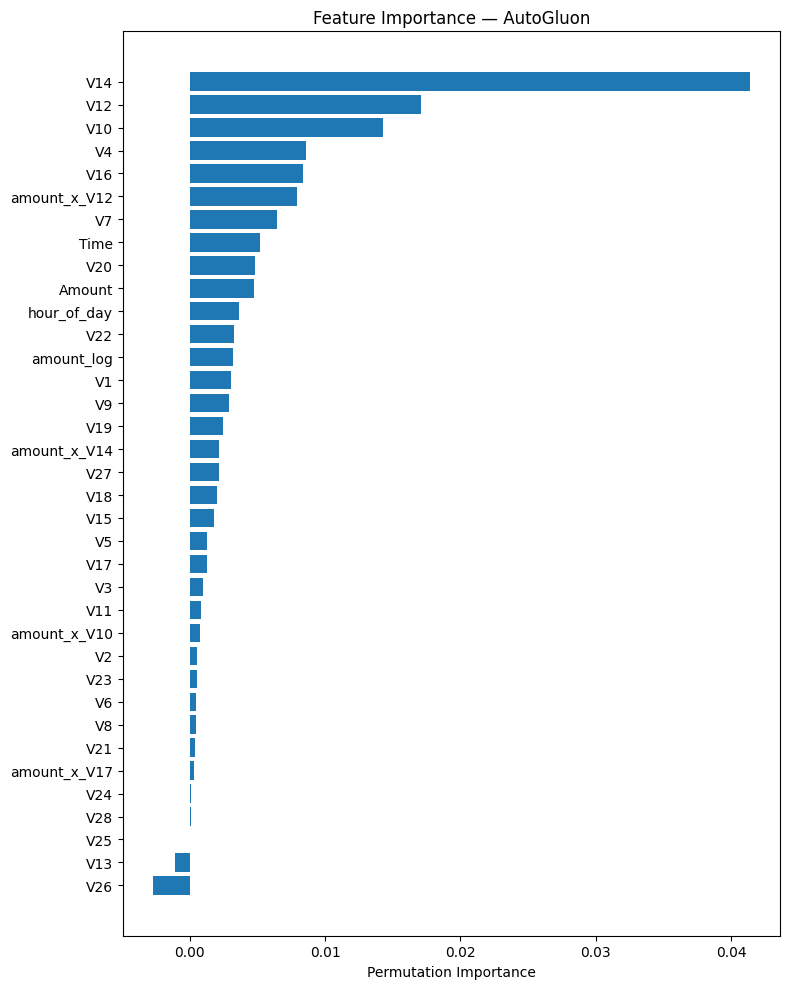

In [20]:
plt.figure(figsize=(8, 10))
importance_sorted = importance.sort_values("importance", ascending=True)
plt.barh(importance_sorted.index, importance_sorted["importance"])
plt.xlabel("Permutation Importance")
plt.title("Feature Importance — AutoGluon")
plt.tight_layout()
plt.show()

In [22]:
selected_features = importance[importance["importance"] > 0].index.tolist()

print(f"Liczba wybranych cech: {len(selected_features)}")
print(selected_features)

Liczba wybranych cech: 34
['V14', 'V12', 'V10', 'V4', 'V16', 'amount_x_V12', 'V7', 'Time', 'V20', 'Amount', 'hour_of_day', 'V22', 'amount_log', 'V1', 'V9', 'V19', 'amount_x_V14', 'V27', 'V18', 'V15', 'V5', 'V17', 'V3', 'V11', 'amount_x_V10', 'V2', 'V23', 'V6', 'V8', 'V21', 'amount_x_V17', 'V24', 'V28', 'V25']


In [24]:
X_train_selected = X_train_fe[selected_features]
X_test_selected = X_test_fe[selected_features]

model_selected = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
)
model_selected.fit(X_train_selected, y_train)

y_proba_selected = model_selected.predict_proba(X_test_selected)[:, 1]
pr_auc_selected = average_precision_score(y_test, y_proba_selected)

print(f"PR-AUC z selekcją cech: {pr_auc_selected:.4f}")
print(f"PR-AUC bez selekcji: {pr_auc_fe:.4f}")

PR-AUC z selekcją cech: 0.7190
PR-AUC bez selekcji: 0.7370


/home/xowski22/Desktop/credit_card_fraud_project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
